# Homework 4

Продолжаю работу с [TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata) и результатами Homework 3.

Правило классификации остаётся прежним:

- **1 — хороший фильм**, если `vote_average > 6`;
- **0 — обычный или плохой фильм**, если `vote_average <= 6`.

В базовой части исследуются kNN, SVM, Logistic Regression, Hard/Soft Voting и AdaBoost. В дополнительных частях выполняются искусственный upsampling, stacking, bagging и добавляется CART.

In [1]:
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import (
    AdaBoostClassifier, BaggingClassifier, StackingClassifier, VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, log_loss, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

movies = pd.read_csv("tmdb_5000_movies.csv")
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
data = movies.loc[movies["vote_average"] > 0].copy()
data["release_year"] = data["release_date"].dt.year
data["good_movie"] = (data["vote_average"] > 6).astype(int)

for col in ["budget", "revenue", "runtime"]:
    data.loc[data[col] == 0, col] = np.nan

data["log_budget"] = np.log1p(data["budget"])
data["log_revenue"] = np.log1p(data["revenue"])
data["log_popularity"] = np.log1p(data["popularity"].clip(lower=0))
data["log_vote_count"] = np.log1p(data["vote_count"])

features = [
    "log_budget", "log_revenue", "log_popularity",
    "runtime", "log_vote_count", "release_year",
]
X = data[features]
y = data["good_movie"]

train_index, test_index = train_test_split(
    data.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_test = X.loc[train_index], X.loc[test_index]
y_train, y_test = y.loc[train_index], y.loc[test_index]

print("объектов:", len(data), "train:", len(X_train), "test:", len(X_test))
display(pd.DataFrame({
    "количество": y.value_counts().sort_index(),
    "доля": y.value_counts(normalize=True).sort_index(),
}, index=[0, 1]).rename(index={0: "оценка <= 6", 1: "оценка > 6"}).round(3))

объектов: 4740 train: 3792 test: 948


,количество,доля
оценка <= 6,1984,0.419
оценка > 6,2756,0.581


## 1. Результаты Homework 3 как исходный уровень

Повторно обучаю три требуемые модели на том же разбиении 80/20. Это исходный уровень для сравнения с кросс-валидацией и композициями.

Для всех моделей используются одинаковые признаки. Пропуски и масштабирование обрабатываются внутри `Pipeline` только по train.

In [2]:
def make_base_models():
    return {
        "kNN": make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(),
            KNeighborsClassifier(n_neighbors=15, weights="distance"),
        ),
        "SVM": make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(),
            SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        ),
        "Logistic Regression": make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(),
            LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        ),
    }


def scores(real, labels, probability):
    probability = np.clip(probability, 1e-7, 1 - 1e-7)
    return {
        "Accuracy": accuracy_score(real, labels),
        "F1": f1_score(real, labels),
        "LogLoss": log_loss(real, probability, labels=[0, 1]),
        "ROC-AUC": roc_auc_score(real, probability),
    }


def evaluate_fitted(models, X_value, y_value):
    labels, probabilities = {}, {}
    for name, model in models.items():
        labels[name] = model.predict(X_value)
        probabilities[name] = model.predict_proba(X_value)[:, 1]
    table = pd.DataFrame({
        name: scores(y_value, labels[name], probabilities[name])
        for name in models
    }).T
    return table, labels, probabilities


def plot_roc_curves(real, probabilities, title):
    plt.figure(figsize=(7, 5))
    for name, probability in probabilities.items():
        fpr, tpr, _ = roc_curve(real, probability)
        auc = roc_auc_score(real, probability)
        plt.plot(fpr, tpr, label=f"{name}: {auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="случайный ответ")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.show()


def plot_confusions(real, labels, title, columns=3):
    rows = int(np.ceil(len(labels) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4.5 * columns, 3.7 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (name, prediction) in zip(axes, labels.items()):
        ConfusionMatrixDisplay(
            confusion_matrix(real, prediction),
            display_labels=["оценка <= 6", "оценка > 6"],
        ).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name)
    for ax in axes[len(labels):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


base_models = make_base_models()
for model in base_models.values():
    model.fit(X_train, y_train)

base_scores, base_labels, base_probabilities = evaluate_fitted(
    base_models, X_test, y_test
)
display(base_scores.sort_values("F1", ascending=False).round(4))

,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.7226,0.7598,0.5547,0.7872
Logistic Regression,0.6920,0.7474,0.5928,0.7457
SVM,0.7141,0.7451,0.5461,0.7875


## 2. K-fold кросс-валидация, k = 5

Используется `StratifiedKFold`: каждый из пяти фолдов сохраняет доли классов. Каждый объект ровно один раз становится проверочным, а его прогноз строится моделью, которая этот объект не видела. Получаются out-of-fold прогнозы для всего набора данных.

Accuracy      F1  LogLoss  ROC-AUC
проверка           модель                                                 
Holdout Homework 3 kNN                    0.7226  0.7598   0.5547   0.7872
                   SVM                    0.7141  0.7451   0.5461   0.7875
                   Logistic Regression    0.6920  0.7474   0.5928   0.7457
5-fold CV          kNN                    0.7251  0.7613   0.5728   0.7918
                   SVM                    0.7338  0.7671   0.5260   0.8061
                   Logistic Regression    0.6926  0.7501   0.5786   0.7619

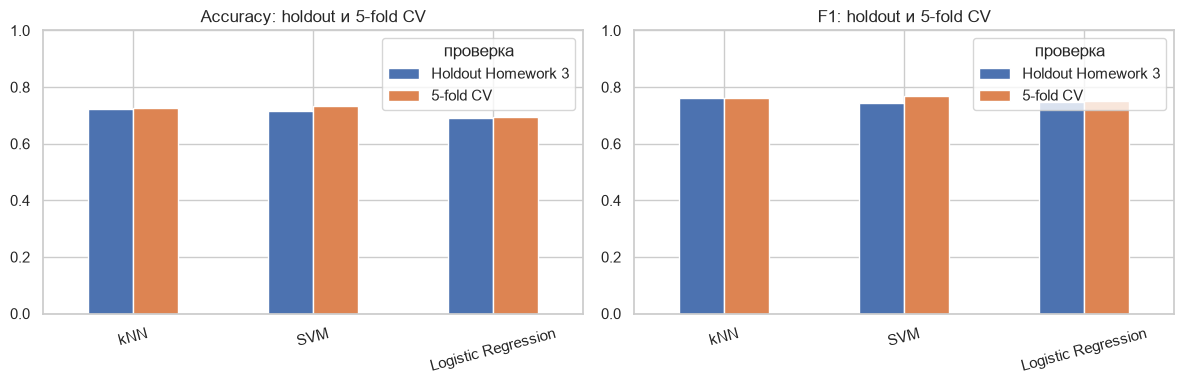

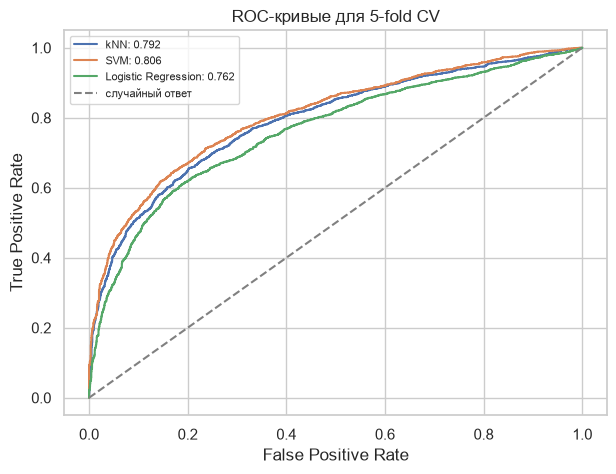

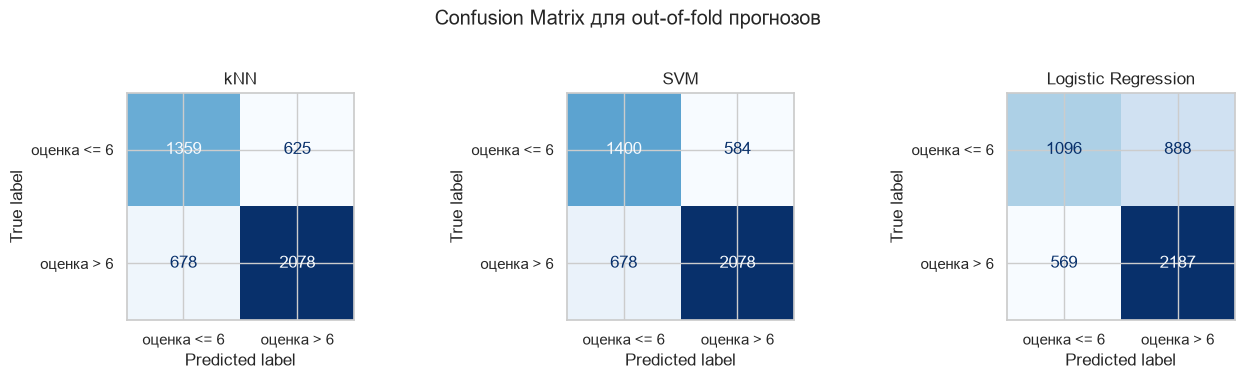

Лучший F1 при 5-fold CV у SVM: 0.767; Accuracy=0.734, ROC-AUC=0.806.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_labels = {name: np.zeros(len(data), dtype=int) for name in base_models}
cv_probabilities = {name: np.zeros(len(data), dtype=float) for name in base_models}

for train_positions, validation_positions in cv.split(X, y):
    X_fold_train, X_fold_valid = X.iloc[train_positions], X.iloc[validation_positions]
    y_fold_train = y.iloc[train_positions]
    for name, prototype in make_base_models().items():
        model = clone(prototype)
        model.fit(X_fold_train, y_fold_train)
        cv_labels[name][validation_positions] = model.predict(X_fold_valid)
        cv_probabilities[name][validation_positions] = model.predict_proba(X_fold_valid)[:, 1]

cv_scores = pd.DataFrame({
    name: scores(y, cv_labels[name], cv_probabilities[name])
    for name in base_models
}).T

comparison_cv = pd.concat(
    {"Результаты ДЗ 3": base_scores, "5-fold CV": cv_scores},
    names=["проверка", "модель"],
)
display(comparison_cv.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison_cv["Accuracy"].unstack(0).plot(kind="bar", ylim=(0, 1), ax=axes[0])
axes[0].set_title("Accuracy: ДЗ3 и 5-fold CV")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)
comparison_cv["F1"].unstack(0).plot(kind="bar", ylim=(0, 1), ax=axes[1])
axes[1].set_title("F1: ДЗ3 и 5-fold CV")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

plot_roc_curves(y, cv_probabilities, "ROC-кривые для 5-fold CV")
plot_confusions(y, cv_labels, "Confusion Matrix для out-of-fold прогнозов")

best_cv = cv_scores["F1"].idxmax()
print(
    f"Лучший F1 при 5-fold CV у {best_cv}: {cv_scores.loc[best_cv, 'F1']:.3f}; "
    f"Accuracy={cv_scores.loc[best_cv, 'Accuracy']:.3f}, "
    f"ROC-AUC={cv_scores.loc[best_cv, 'ROC-AUC']:.3f}."
)

**Интерпретация кросс-валидации.** kNN и Logistic Regression дали почти одинаковые результаты на holdout и при 5-fold CV, поэтому их оценки устойчивы к разбиению. SVM на кросс-валидации улучшилась: Accuracy выросла с 0.714 до 0.734, F1 — с 0.745 до 0.767, ROC-AUC — с 0.788 до 0.806. Поэтому лучшей базовой моделью по более надёжной 5-fold оценке является SVM. Все ROC-кривые заметно выше случайной диагонали. По матрицам ошибок SVM правильно определила 1400 фильмов класса 0 и 2078 хороших фильмов; Logistic Regression нашла больше хороших фильмов, но дала значительно больше ложных срабатываний класса 1.

## 3. Hard Voting и Soft Voting

В композицию входят kNN, SVM и Logistic Regression.

- **Hard Voting** выбирает класс большинством голосов. Для ROC и LogLoss используется доля голосов за класс 1: 0, 1/3, 2/3 или 1.
- **Soft Voting** усредняет вероятности класса 1 и затем применяет порог 0.5.

,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.7226,0.7598,0.5547,0.7872
Hard Voting,0.7226,0.7580,2.8842,0.7521
Soft Voting,0.7152,0.7554,0.5385,0.7919
Logistic Regression,0.6920,0.7474,0.5928,0.7457
SVM,0.7141,0.7451,0.5461,0.7875


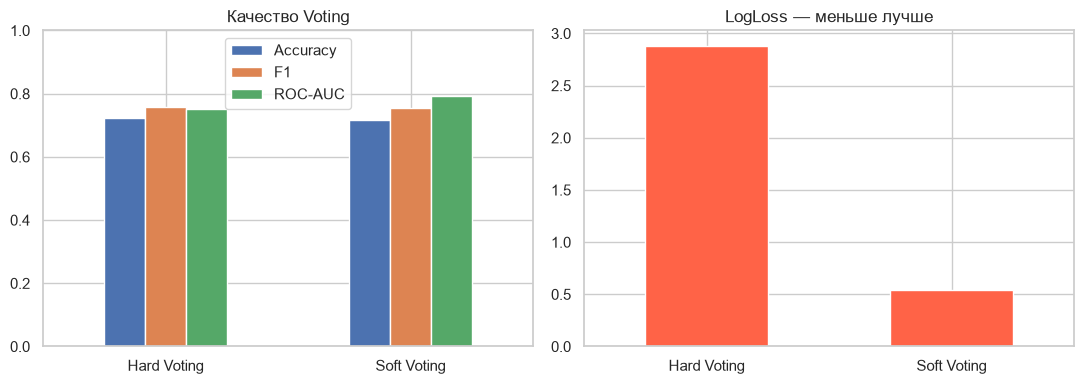

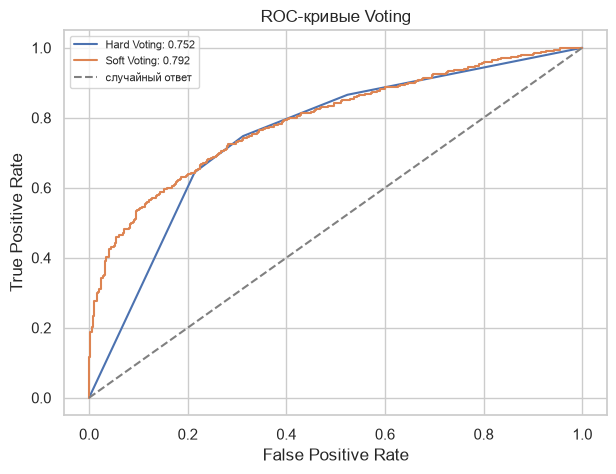

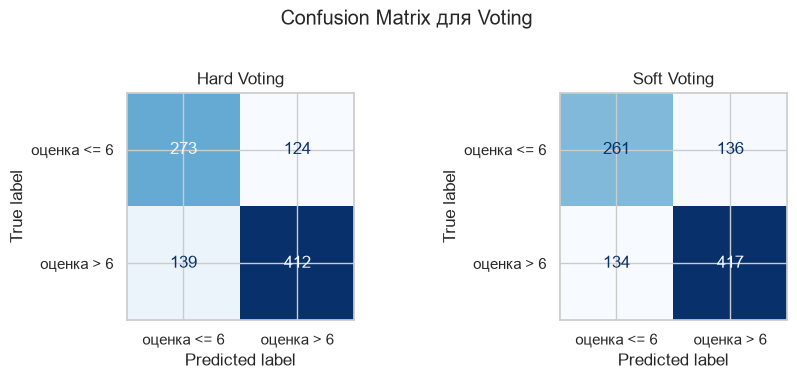

Лучший вариант голосования — Hard Voting: F1=0.758, Accuracy=0.723.


In [4]:
voting_estimators = [
    ("knn", make_base_models()["kNN"]),
    ("svm", make_base_models()["SVM"]),
    ("logistic", make_base_models()["Logistic Regression"]),
]

hard_voting = VotingClassifier(estimators=voting_estimators, voting="hard")
soft_voting = VotingClassifier(estimators=voting_estimators, voting="soft")
hard_voting.fit(X_train, y_train)
soft_voting.fit(X_train, y_train)

voting_labels = {
    "Hard Voting": hard_voting.predict(X_test),
    "Soft Voting": soft_voting.predict(X_test),
}
hard_probability = np.mean(
    [estimator.predict(X_test) for estimator in hard_voting.estimators_], axis=0
)
voting_probabilities = {
    "Hard Voting": hard_probability,
    "Soft Voting": soft_voting.predict_proba(X_test)[:, 1],
}
voting_scores = pd.DataFrame({
    name: scores(y_test, voting_labels[name], voting_probabilities[name])
    for name in voting_labels
}).T

display(pd.concat([base_scores, voting_scores]).sort_values("F1", ascending=False).round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
voting_scores[["Accuracy", "F1", "ROC-AUC"]].plot(kind="bar", ylim=(0, 1), ax=axes[0])
axes[0].set_title("Качество Voting")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
voting_scores["LogLoss"].plot(kind="bar", color="tomato", ax=axes[1])
axes[1].set_title("LogLoss — меньше лучше")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

plot_roc_curves(y_test, voting_probabilities, "ROC-кривые Voting")
plot_confusions(y_test, voting_labels, "Confusion Matrix для Voting", columns=2)

best_voting = voting_scores["F1"].idxmax()
print(
    f"Лучший вариант голосования — {best_voting}: "
    f"F1={voting_scores.loc[best_voting, 'F1']:.3f}, "
    f"Accuracy={voting_scores.loc[best_voting, 'Accuracy']:.3f}."
)

**Интерпретация Voting.** Hard Voting немного лучше по готовым классам: Accuracy = 0.723 и F1 = 0.758 против 0.715 и 0.755 у Soft Voting. Однако Soft Voting значительно лучше по вероятностным метрикам: ROC-AUC = 0.792 и LogLoss = 0.538. Большой LogLoss Hard Voting, равный 2.884, объясняется грубыми вероятностями 0, 1/3, 2/3 и 1: единогласная неправильная классификация получает чрезмерный штраф. Матрицы ошибок близки; Soft Voting нашёл на пять хороших фильмов больше, но также увеличил число ложных срабатываний на 12. Для классов можно выбрать Hard Voting, а для вероятностей — Soft Voting.

## 4. AdaBoost с деревом решений

Базовый алгоритм AdaBoost — слабое дерево глубины 1. Последовательно строятся 150 деревьев, причём каждый следующий алгоритм уделяет больше внимания объектам, на которых ошиблась предыдущая композиция.

,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.7226,0.7598,0.5547,0.7872
Hard Voting,0.7226,0.7580,2.8842,0.7521
Soft Voting,0.7152,0.7554,0.5385,0.7919
AdaBoost,0.6962,0.7496,0.6228,0.7629
Logistic Regression,0.6920,0.7474,0.5928,0.7457
SVM,0.7141,0.7451,0.5461,0.7875


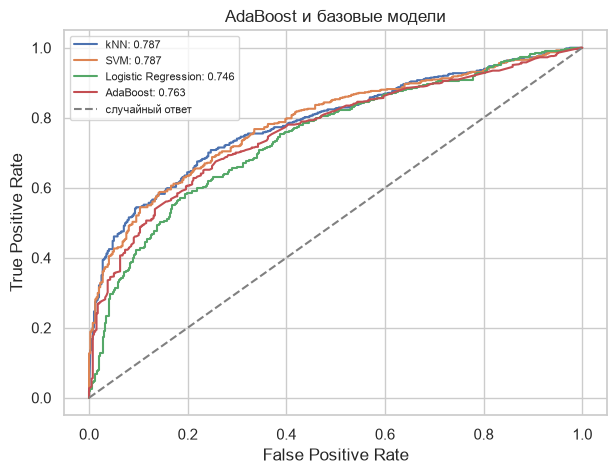

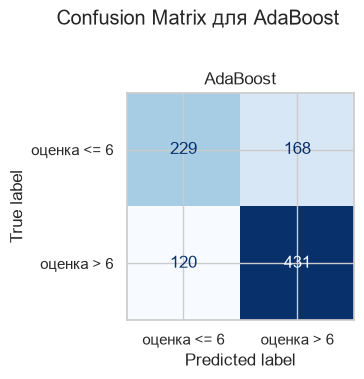

AdaBoost: Accuracy=0.696, F1=0.750, ROC-AUC=0.763.


In [5]:
adaboost = make_pipeline(
    SimpleImputer(strategy="median"),
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        n_estimators=150,
        learning_rate=0.5,
        random_state=RANDOM_STATE,
    ),
)
adaboost.fit(X_train, y_train)
ada_labels = {"AdaBoost": adaboost.predict(X_test)}
ada_probabilities = {"AdaBoost": adaboost.predict_proba(X_test)[:, 1]}
ada_scores = pd.DataFrame({
    "AdaBoost": scores(y_test, ada_labels["AdaBoost"], ada_probabilities["AdaBoost"])
}).T

display(pd.concat([base_scores, voting_scores, ada_scores]).sort_values("F1", ascending=False).round(4))
plot_roc_curves(
    y_test,
    {**base_probabilities, **ada_probabilities},
    "AdaBoost и базовые модели",
)
plot_confusions(y_test, ada_labels, "Confusion Matrix для AdaBoost", columns=1)

print(
    f"AdaBoost: Accuracy={ada_scores.loc['AdaBoost', 'Accuracy']:.3f}, "
    f"F1={ada_scores.loc['AdaBoost', 'F1']:.3f}, "
    f"ROC-AUC={ada_scores.loc['AdaBoost', 'ROC-AUC']:.3f}."
)

**Интерпретация AdaBoost.** AdaBoost получил Accuracy = 0.696, F1 = 0.750 и ROC-AUC = 0.763. Он лучше Logistic Regression по F1 и ROC-AUC, но уступает kNN и SVM. По матрице ошибок модель правильно определила 431 хороший фильм и пропустила 120, однако 168 фильмов класса 0 ошибочно признала хорошими. Следовательно, последовательное исправление ошибок слабых деревьев не стало лучшим вариантом для этого набора признаков.

## Дополнительная часть +1: искусственный upsampling

В train класс 0 меньше класса 1. Для него создаются синтетические объекты методом интерполяции: выбирается объект меньшинства, один из его ближайших соседей того же класса и случайная точка на отрезке между ними. Test не изменяется и не участвует в генерации.

,до upsampling,после upsampling
0,1587,2205
1,2205,2205


,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.7226,0.7598,0.5547,0.7872
SVM,0.7141,0.7451,0.5461,0.7875
kNN + upsampling,0.7173,0.7320,0.5884,0.7857
SVM + upsampling,0.7046,0.7160,0.5504,0.7904


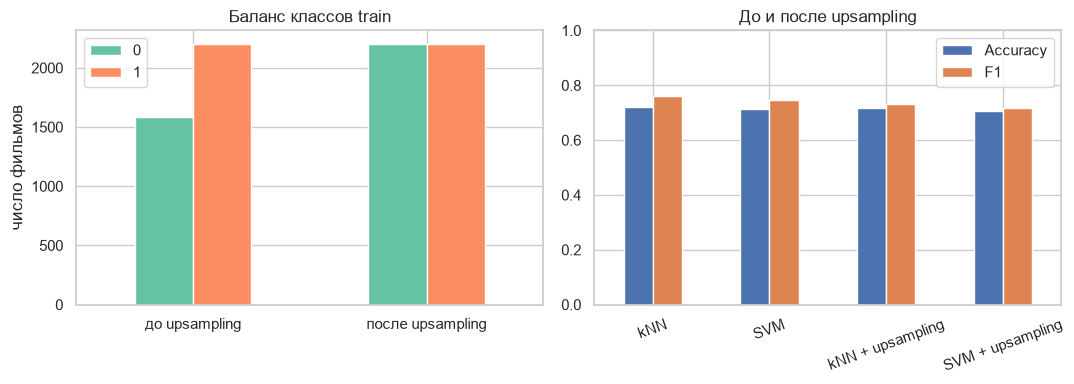

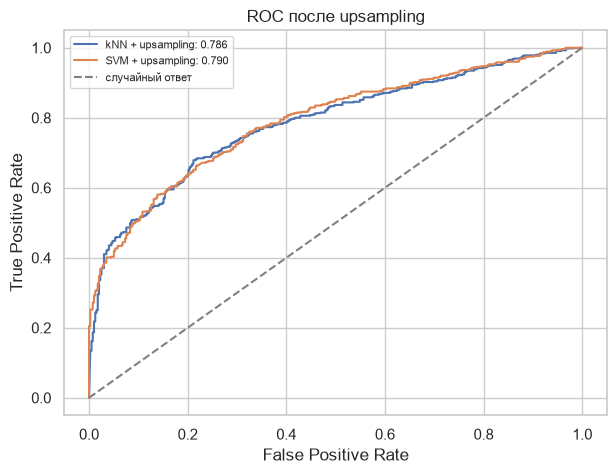

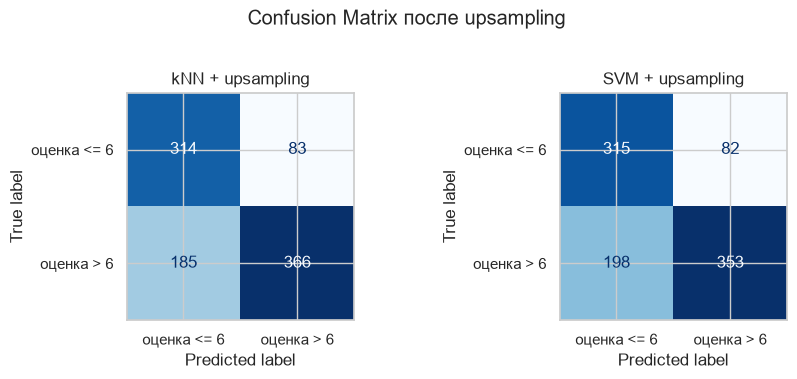

Число объектов train до/после: 3792 / 4410


In [6]:
preprocessor = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)
y_train_array = y_train.to_numpy()


def synthetic_upsample(X_values, y_values, random_state=42, neighbors=5):
    rng = np.random.default_rng(random_state)
    classes, counts = np.unique(y_values, return_counts=True)
    minority = classes[np.argmin(counts)]
    majority_count = counts.max()
    minority_values = X_values[y_values == minority]
    need = majority_count - len(minority_values)

    nearest = NearestNeighbors(n_neighbors=min(neighbors + 1, len(minority_values)))
    nearest.fit(minority_values)
    neighbor_indices = nearest.kneighbors(return_distance=False)

    synthetic = []
    for _ in range(need):
        i = rng.integers(len(minority_values))
        candidates = neighbor_indices[i][neighbor_indices[i] != i]
        j = rng.choice(candidates)
        weight = rng.random()
        synthetic.append(minority_values[i] + weight * (minority_values[j] - minority_values[i]))

    X_new = np.vstack([X_values, np.asarray(synthetic)])
    y_new = np.concatenate([y_values, np.full(need, minority)])
    order = rng.permutation(len(y_new))
    return X_new[order], y_new[order]


X_upsampled, y_upsampled = synthetic_upsample(X_train_scaled, y_train_array, RANDOM_STATE)

before_counts = pd.Series(y_train_array).value_counts().sort_index()
after_counts = pd.Series(y_upsampled).value_counts().sort_index()
balance_table = pd.DataFrame({"до upsampling": before_counts, "после upsampling": after_counts})
display(balance_table)

upsampled_models = {
    "kNN + upsampling": KNeighborsClassifier(n_neighbors=15, weights="distance"),
    "SVM + upsampling": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}
for model in upsampled_models.values():
    model.fit(X_upsampled, y_upsampled)

upsampled_scores, upsampled_labels, upsampled_probabilities = evaluate_fitted(
    upsampled_models, X_test_scaled, y_test
)
upsampling_comparison = pd.concat([
    base_scores.loc[["kNN", "SVM"]],
    upsampled_scores,
])
display(upsampling_comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
balance_table.T.plot(kind="bar", ax=axes[0], color=["#66c2a5", "#fc8d62"])
axes[0].set_title("Баланс классов train")
axes[0].set_xlabel("")
axes[0].set_ylabel("число фильмов")
axes[0].tick_params(axis="x", rotation=0)
upsampling_comparison[["Accuracy", "F1"]].plot(kind="bar", ylim=(0, 1), ax=axes[1])
axes[1].set_title("До и после upsampling")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

plot_roc_curves(y_test, upsampled_probabilities, "ROC после upsampling")
plot_confusions(y_test, upsampled_labels, "Confusion Matrix после upsampling", columns=2)

print("Число объектов train до/после:", len(X_train), "/", len(X_upsampled))

**Интерпретация upsampling.** Число объектов класса 0 увеличено с 1587 до 2205, поэтому train стал точно сбалансированным — 2205/2205. После upsampling kNN снизила Accuracy с 0.723 до 0.717 и F1 с 0.760 до 0.732; SVM — с 0.714 до 0.705 и с 0.745 до 0.716. При этом ROC-AUC SVM немного вырос с 0.788 до 0.790. Матрицы объясняют снижение F1: модели стали лучше находить класс 0 (314–315 правильных ответов), но начали пропускать больше хороших фильмов — 185 у kNN и 198 у SVM. Балансировка устранила предпочтение большинства, но не улучшила итоговые классы.

## Дополнительная часть +1: Stacking

Базовые уровни — kNN, SVM и Logistic Regression. Их out-of-fold вероятности становятся признаками для итоговой Logistic Regression. Stacking обучается на сбалансированном наборе после upsampling.

,Accuracy,F1,LogLoss,ROC-AUC
Hard Voting,0.7226,0.7580,2.8842,0.7521
Soft Voting,0.7152,0.7554,0.5385,0.7919
Stacking,0.7247,0.7468,0.5461,0.7944
kNN + upsampling,0.7173,0.7320,0.5884,0.7857
SVM + upsampling,0.7046,0.7160,0.5504,0.7904


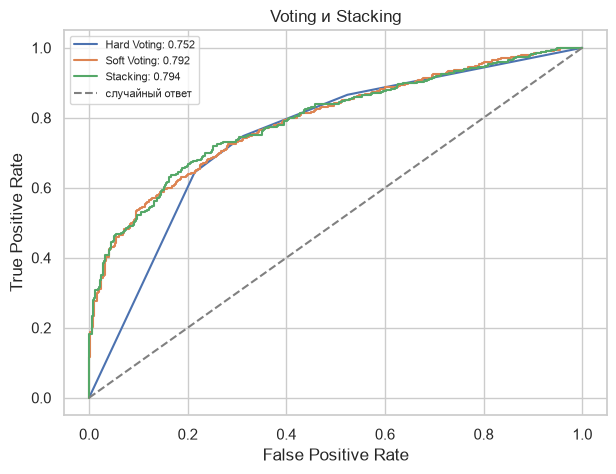

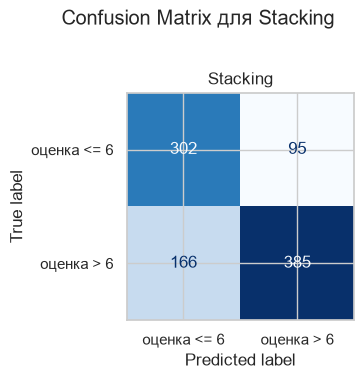

Stacking: Accuracy=0.725, F1=0.747, LogLoss=0.546.


In [7]:
stacking = StackingClassifier(
    estimators=[
        ("knn", KNeighborsClassifier(n_neighbors=15, weights="distance")),
        ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
        ("logistic", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    stack_method="predict_proba",
    cv=5,
)
stacking.fit(X_upsampled, y_upsampled)
stacking_labels = {"Stacking": stacking.predict(X_test_scaled)}
stacking_probabilities = {"Stacking": stacking.predict_proba(X_test_scaled)[:, 1]}
stacking_scores = pd.DataFrame({
    "Stacking": scores(y_test, stacking_labels["Stacking"], stacking_probabilities["Stacking"])
}).T

display(pd.concat([voting_scores, upsampled_scores, stacking_scores]).sort_values("F1", ascending=False).round(4))
plot_roc_curves(
    y_test,
    {**voting_probabilities, **stacking_probabilities},
    "Voting и Stacking",
)
plot_confusions(y_test, stacking_labels, "Confusion Matrix для Stacking", columns=1)

print(
    f"Stacking: Accuracy={stacking_scores.loc['Stacking', 'Accuracy']:.3f}, "
    f"F1={stacking_scores.loc['Stacking', 'F1']:.3f}, "
    f"LogLoss={stacking_scores.loc['Stacking', 'LogLoss']:.3f}."
)

**Интерпретация Stacking.** Stacking показал Accuracy = 0.725 — немного выше Voting, а его ROC-AUC = 0.794 стал лучшим среди этих композиций. Однако F1 = 0.747 ниже Hard/Soft Voting, а LogLoss = 0.546 хуже Soft Voting с 0.538. По матрице ошибок stacking хорошо распознаёт класс 0 (302 объекта), но пропускает 166 хороших фильмов. Метамодель улучшила ранжирование и общую точность, но не стала лучшей по F1.

## Дополнительная часть +2: CART и Bagging

Пятым отдельным алгоритмом становится **CART**: теперь сравниваются kNN, SVM, Logistic Regression, AdaBoost и CART.

Правило разбиения для bagging: строятся 100 CART-деревьев; каждое получает случайную bootstrap-выборку размером 70 % train с возвращением. Итоговая вероятность — среднее вероятностей деревьев, класс определяется большинством.

Пять отдельных алгоритмов:


,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.7226,0.7598,0.5547,0.7872
AdaBoost,0.6962,0.7496,0.6228,0.7629
Logistic Regression,0.6920,0.7474,0.5928,0.7457
SVM,0.7141,0.7451,0.5461,0.7875
CART,0.6962,0.7120,0.6182,0.7463


CART и его bagging-композиция:


,Accuracy,F1,LogLoss,ROC-AUC
Bagging CART,0.7141,0.7493,0.5427,0.7880
CART,0.6962,0.7120,0.6182,0.7463


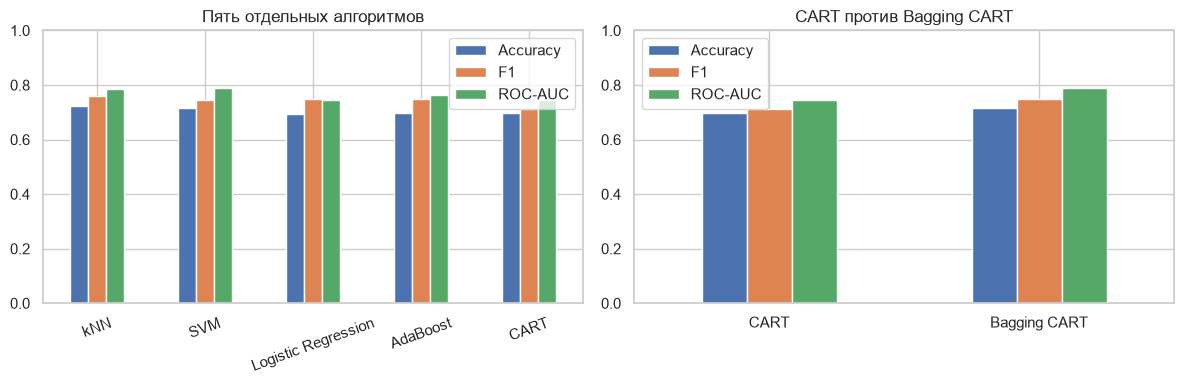

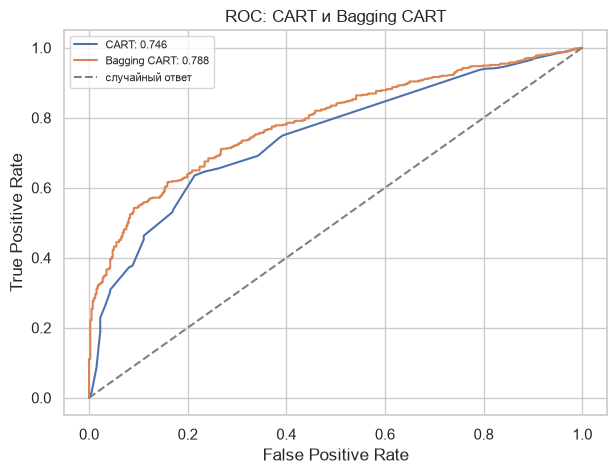

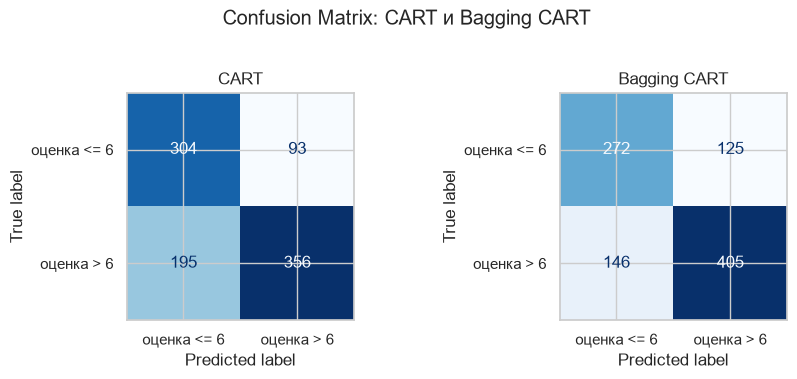

Изменение Bagging относительно CART:  Accuracy +0.018, F1 +0.037, ROC-AUC +0.042.


In [8]:
cart = make_pipeline(
    SimpleImputer(strategy="median"),
    DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE),
)
bagging = make_pipeline(
    SimpleImputer(strategy="median"),
    BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=5, min_samples_leaf=10, random_state=RANDOM_STATE
        ),
        n_estimators=100,
        max_samples=0.7,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
)
cart.fit(X_train, y_train)
bagging.fit(X_train, y_train)

tree_models = {"CART": cart, "Bagging CART": bagging}
tree_scores, tree_labels, tree_probabilities = evaluate_fitted(tree_models, X_test, y_test)

five_individual_scores = pd.concat([
    base_scores,
    ada_scores,
    tree_scores.loc[["CART"]],
])
print("Пять отдельных алгоритмов:")
display(five_individual_scores.sort_values("F1", ascending=False).round(4))
print("CART и его bagging-композиция:")
display(tree_scores.sort_values("F1", ascending=False).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
five_individual_scores[["Accuracy", "F1", "ROC-AUC"]].plot(
    kind="bar", ylim=(0, 1), ax=axes[0]
)
axes[0].set_title("Пять отдельных алгоритмов")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
tree_scores[["Accuracy", "F1", "ROC-AUC"]].plot(kind="bar", ylim=(0, 1), ax=axes[1])
axes[1].set_title("CART против Bagging CART")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

plot_roc_curves(y_test, tree_probabilities, "ROC: CART и Bagging CART")
plot_confusions(y_test, tree_labels, "Confusion Matrix: CART и Bagging CART", columns=2)

print(
    "Изменение Bagging относительно CART: ",
    f"Accuracy {tree_scores.loc['Bagging CART', 'Accuracy'] - tree_scores.loc['CART', 'Accuracy']:+.3f},",
    f"F1 {tree_scores.loc['Bagging CART', 'F1'] - tree_scores.loc['CART', 'F1']:+.3f},",
    f"ROC-AUC {tree_scores.loc['Bagging CART', 'ROC-AUC'] - tree_scores.loc['CART', 'ROC-AUC']:+.3f}."
)

**Интерпретация CART и Bagging.** Одиночный CART уступил большинству моделей: Accuracy = 0.696, F1 = 0.712, ROC-AUC = 0.746. Bagging повысил эти значения до 0.714, 0.749 и 0.788 соответственно, а LogLoss уменьшился с 0.618 до 0.543. Усреднение деревьев сократило число пропущенных хороших фильмов со 195 до 146, хотя ложных срабатываний стало больше — 125 вместо 93. Таким образом, bootstrap-выборки заметно снизили нестабильность отдельного дерева.

## Итоговое сравнение

,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.7226,0.7598,0.5547,0.7872
Hard Voting,0.7226,0.7580,2.8842,0.7521
Soft Voting,0.7152,0.7554,0.5385,0.7919
AdaBoost,0.6962,0.7496,0.6228,0.7629
Bagging CART,0.7141,0.7493,0.5427,0.7880
Logistic Regression,0.6920,0.7474,0.5928,0.7457
Stacking,0.7247,0.7468,0.5461,0.7944
SVM,0.7141,0.7451,0.5461,0.7875
kNN + upsampling,0.7173,0.7320,0.5884,0.7857
SVM + upsampling,0.7046,0.7160,0.5504,0.7904


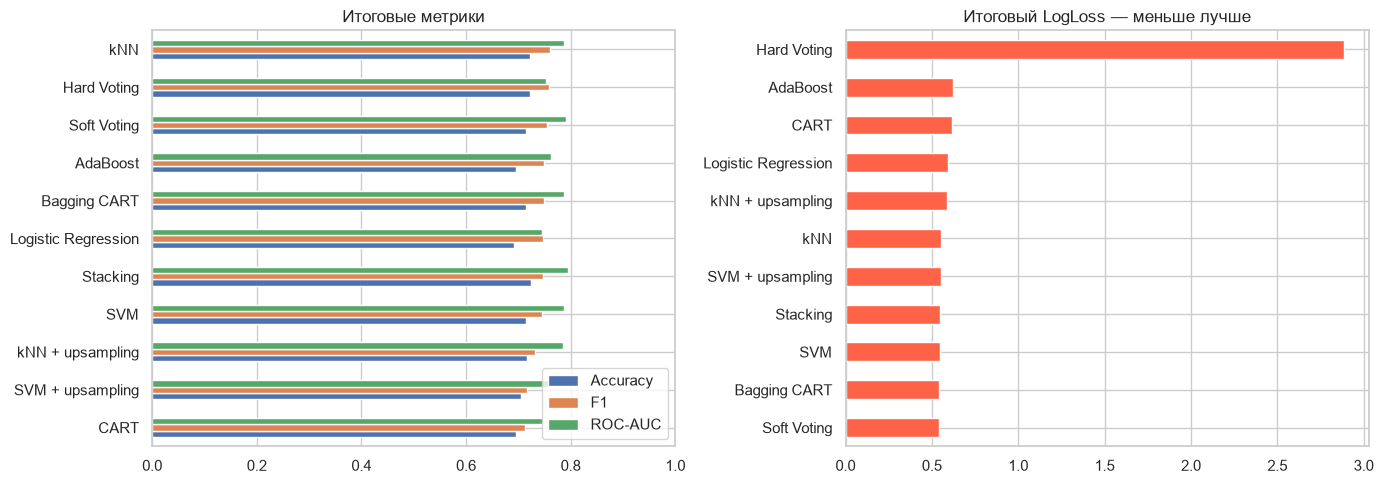

Лучший F1: kNN — 0.760; Accuracy=0.723.
Лучший ROC-AUC: Stacking — 0.794.
Минимальный LogLoss: Soft Voting — 0.538.


In [9]:
all_scores = pd.concat([
    base_scores,
    voting_scores,
    ada_scores,
    upsampled_scores,
    stacking_scores,
    tree_scores,
])
all_scores = all_scores[~all_scores.index.duplicated(keep="last")]
display(all_scores.sort_values(["F1", "ROC-AUC"], ascending=False).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
all_scores.sort_values("F1")[["Accuracy", "F1", "ROC-AUC"]].plot(
    kind="barh", xlim=(0, 1), ax=axes[0]
)
axes[0].set_title("Итоговые метрики")
axes[0].set_ylabel("")
all_scores.sort_values("LogLoss")["LogLoss"].plot(kind="barh", color="tomato", ax=axes[1])
axes[1].set_title("Итоговый LogLoss — меньше лучше")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

best_f1 = all_scores["F1"].idxmax()
best_auc = all_scores["ROC-AUC"].idxmax()
best_loss = all_scores["LogLoss"].idxmin()
print(
    f"Лучший F1: {best_f1} — {all_scores.loc[best_f1, 'F1']:.3f}; "
    f"Accuracy={all_scores.loc[best_f1, 'Accuracy']:.3f}."
)
print(f"Лучший ROC-AUC: {best_auc} — {all_scores.loc[best_auc, 'ROC-AUC']:.3f}.")
print(f"Минимальный LogLoss: {best_loss} — {all_scores.loc[best_loss, 'LogLoss']:.3f}.")

**Общий вывод.** 5-fold CV показала лучшую устойчивую базовую оценку у SVM. Среди всех holdout-вариантов максимальный F1 = 0.760 сохранил kNN, максимальный ROC-AUC = 0.794 получил Stacking, а минимальный LogLoss = 0.538 — Soft Voting. Bagging существенно улучшил одиночный CART по всем четырём метрикам. Искусственный upsampling точно выровнял классы, но снизил Accuracy и F1, поскольку модели стали чаще относить хорошие фильмы к классу 0. Следовательно, для готовой метки лучше kNN, для ранжирования — Stacking, а для вероятностей — Soft Voting.